# Plasma deceleration analysis - 02/04/2026

In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import sys
sys.path.append(r'D:\CLARA\HALHF_at_CLARA\online_analysis')

from HALHF_CLARA_analysis.CLARA_dataset import CLARADataset
from HALHF_CLARA_analysis.utils.colors import FLASHForward as FF_cmap
from HALHF_CLARA_analysis.plotting import plot_grouped_waterfall


# sys.path.append(r'D:\CLARA\HALHF_at_CLARA')
# from HALHF_CLARA_controls import FEBE_sectio


In [4]:
#%% set plot styles
import matplotlib as mpl

mpl.rcParams["figure.figsize"] = (12, 6)
mpl.rc("xtick", labelsize=16)
mpl.rc("ytick", labelsize=16)
mpl.rc("font", size=18)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=["navy", "orange", "mediumseagreen", "dodgerblue", "blueviolet", "gold"]
)

norm = lambda x , xa : (x-np.min(xa))/(np.max(xa)-np.min(xa))

In [32]:
ESPEC_px2mm = 0.0453 #mm/px
ESPEC_Dx_design = 620 #mm
ESPEC_Dx_meas = 752 #mm
E0 = 250 # MeV

## Background data

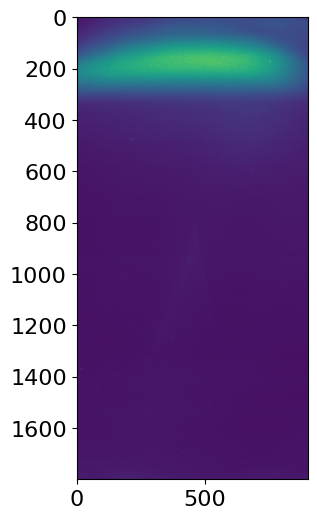

In [5]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_185150.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')
data = dset.load_data(['CLA-FED-DIA-CAM-02'])
bg_image = data['CLA-FED-DIA-CAM-02'].iloc[0]

plt.figure()
plt.imshow(bg_image)

## Uncompressed beam
* Primarily a lensing effect seen

(<Figure size 2400x800 with 2 Axes>,
 <Axes: xlabel='Discharge Timing [$\\mu$s]', ylabel='x'>)

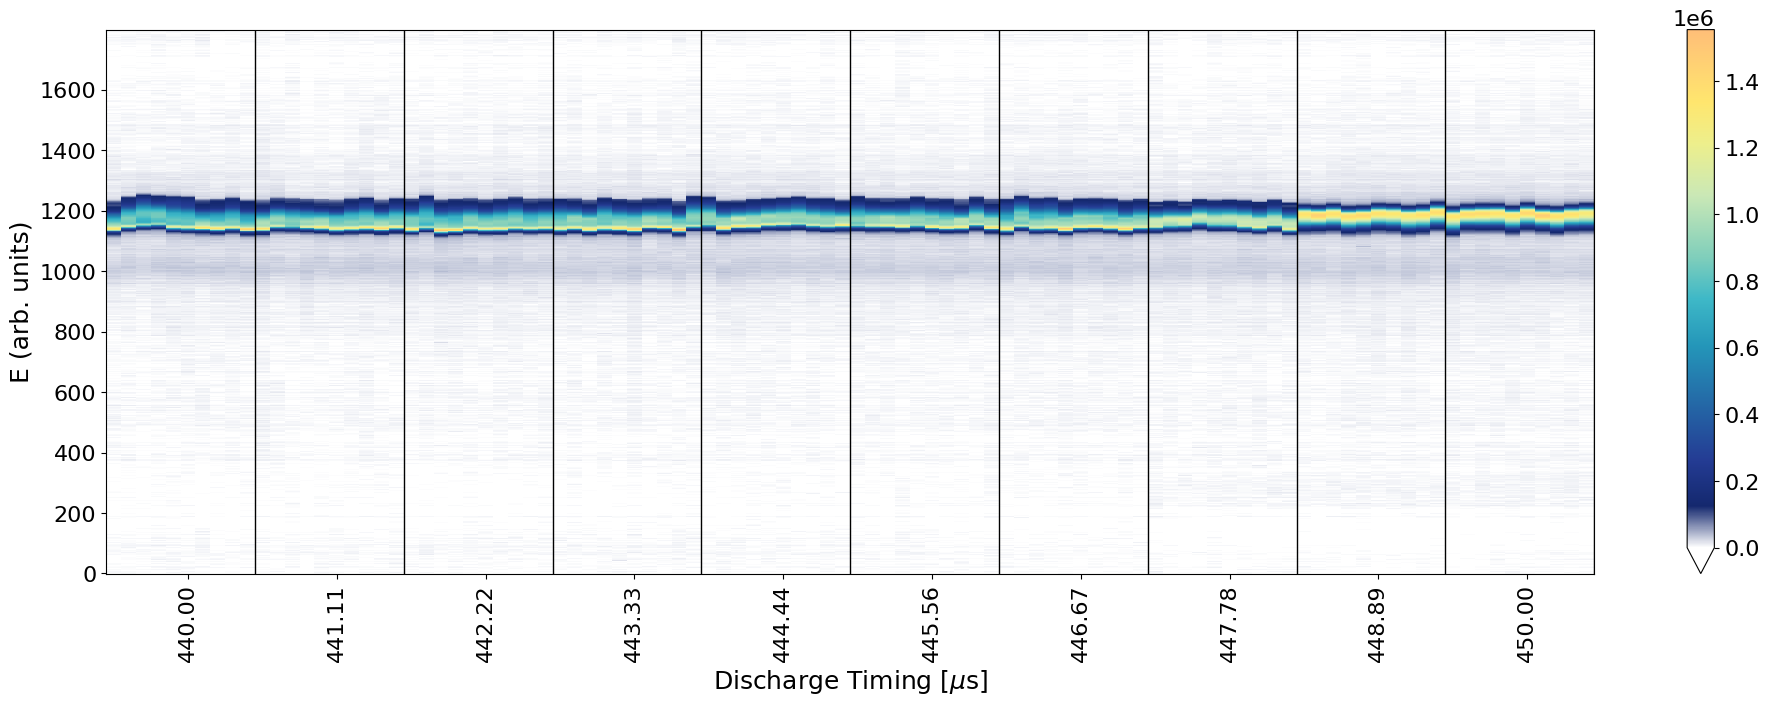

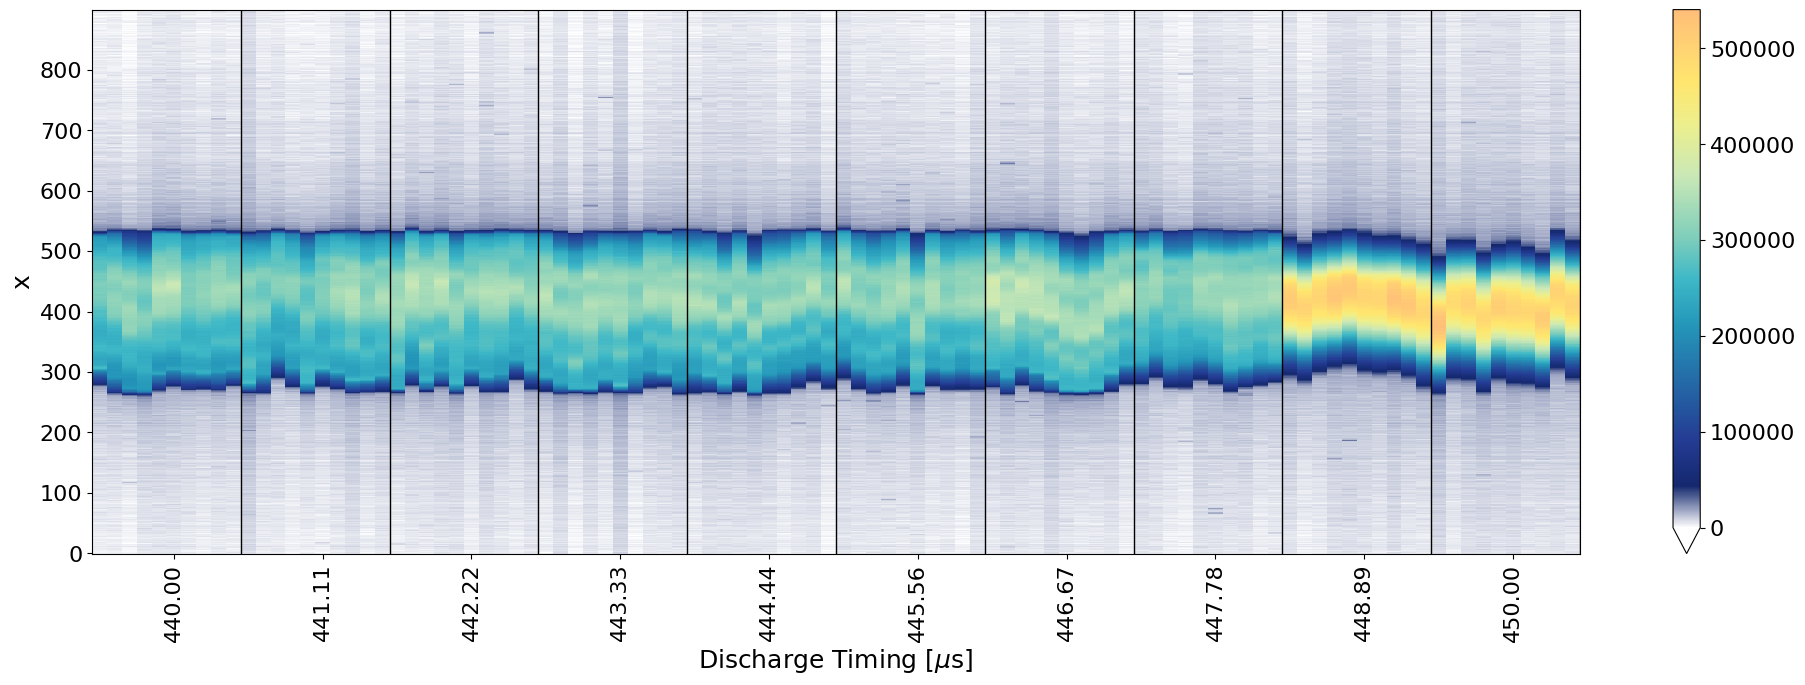

In [15]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_182435.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')

plot_grouped_waterfall(data.xprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)

In [6]:
plot_grouped_waterfall?

Signature:
plot_grouped_waterfall(
    traces,
    group_values: Optional[List[float]] = None,
    group_label: Optional[str] = None,
    group_units: Optional[str] = None,
    coord_name='x',
    figsize: Tuple[int, int] = (24, 8),
    xtick_rotation: int = 90,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    cmap='magma',
    ax: Optional[matplotlib.axes._axes.Axes] = None,
    add_colorbar: bool = True,
    cbar_ax=None,
    linestyle: str = '-',
    linealpha: float = 1,
    linecolor: str = 'k',
    linewidth: float = 1,
    norm: Optional[matplotlib.colors.Normalize] = None,
    rasterize: bool = False,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes._axes.Axes]
Docstring:
Plots a grouped waterfall plot.

Parameters:
- traces (List[xr.DataArray]): The trace data to plot.
- group_values (Optional[List[float]], optional): Values to group the traces by.
- group_label (Optional[str], optional): Label for the group axis.
- group_units (Optional[str], option

## First deceleration

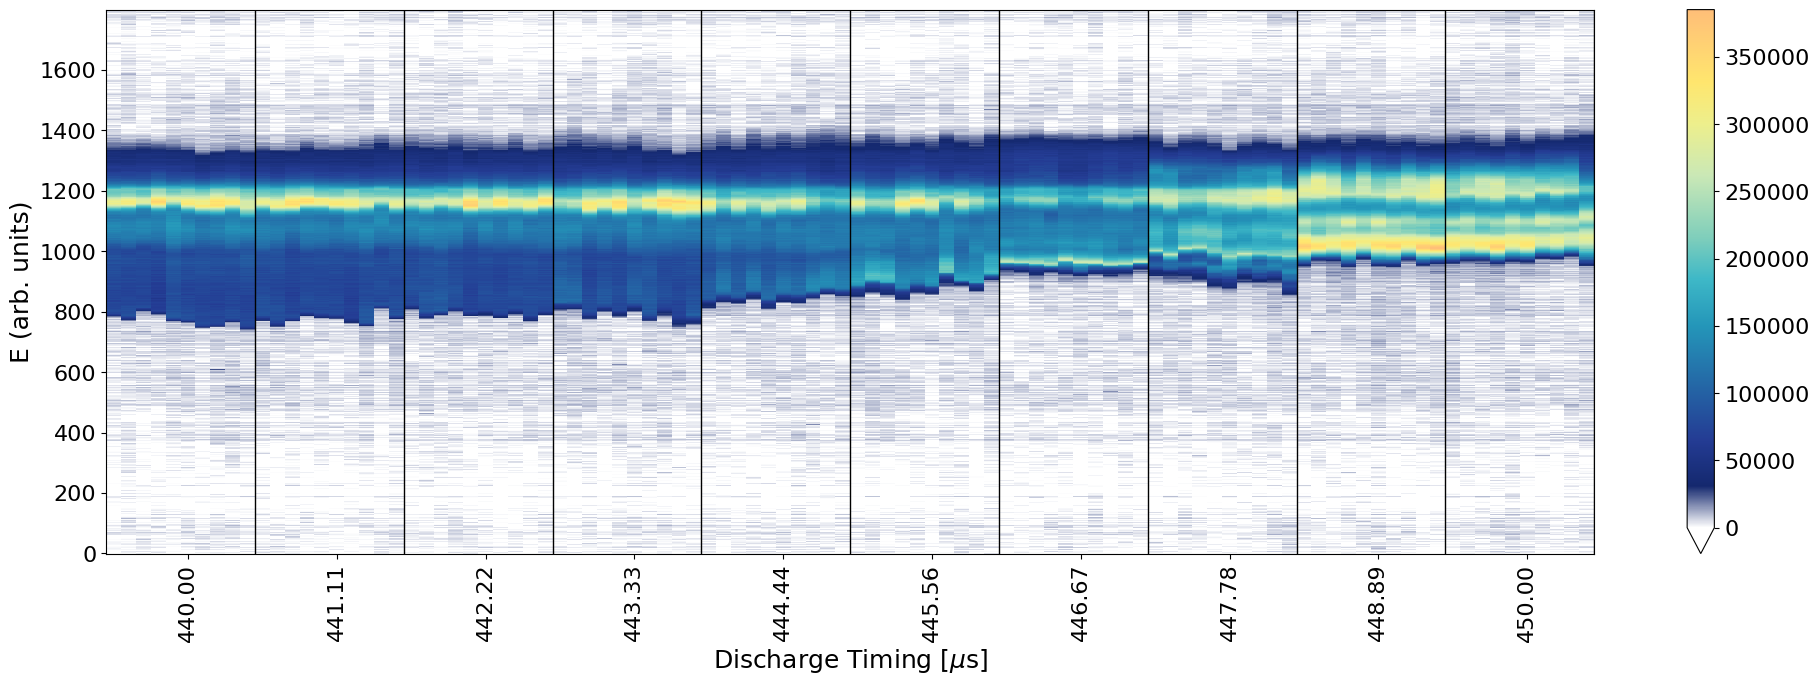

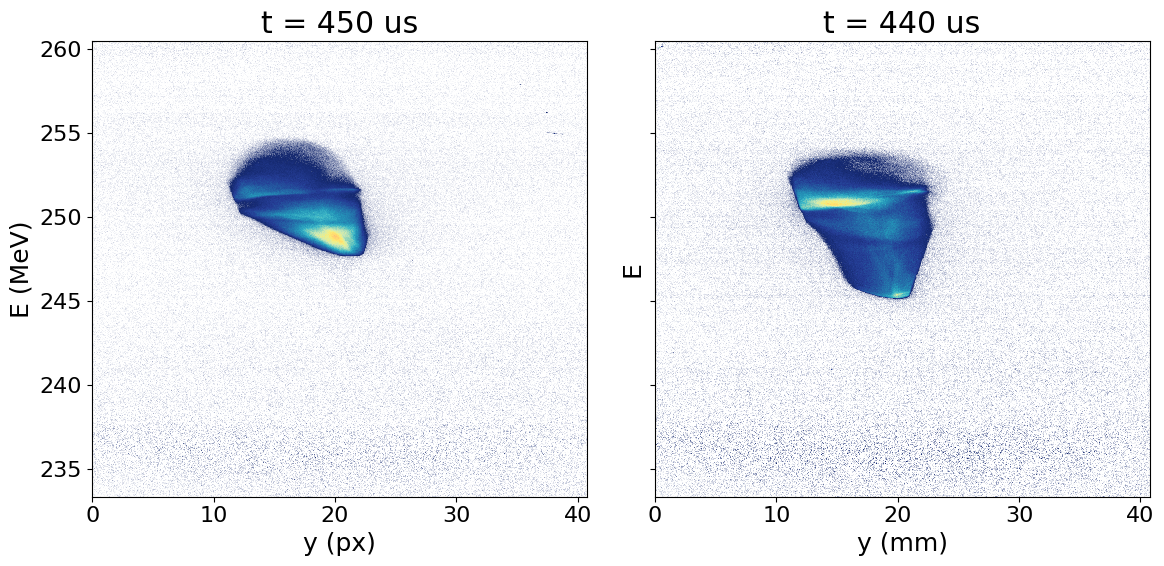

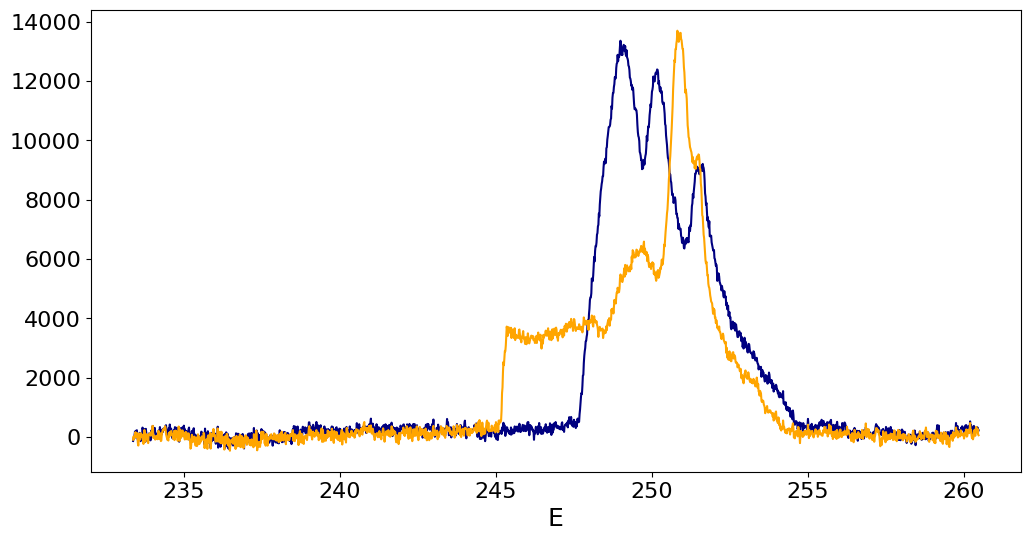

In [39]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_183411.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')

fig , axs = plt.subplots(ncols = 2 , sharey = True)

fig_spec , ax_spec = plt.subplots()

im = data.ESPEC.iloc[-1]
im = xr.DataArray(im , coords = {'E' : np.arange(0 , im.shape[0] , 1) , 'y' : np.arange(0 , im.shape[1] , 1)})
im['E'] = im.E * ESPEC_px2mm - 50
im['E'] = im.E / ESPEC_Dx_meas
im['E'] = E0 * (1 + im.E)
im['y'] = im.y * ESPEC_px2mm

im.plot(ax = axs[0] , cmap = FF_cmap , add_colorbar = False , vmin = 0)
axs[0].set_title(f't = 450 us')
axs[0].set_ylabel('E (MeV)')
axs[0].set_xlabel('y (px)')

im.integrate('y').plot(ax = ax_spec)

im = data.ESPEC.iloc[0]
im = xr.DataArray(im , coords = {'E' : np.arange(0 , im.shape[0] , 1) , 'y' : np.arange(0 , im.shape[1] , 1)})
im['E'] = im.E * ESPEC_px2mm - 50
im['E'] = im.E / ESPEC_Dx_meas
im['E'] = E0 * (1 + im.E)
im['y'] = im.y * ESPEC_px2mm
im.plot(ax = axs[-1] , cmap = FF_cmap , add_colorbar = False , vmin = 0)
axs[-1].set_title(f't = 440 us')
axs[-1].set_xlabel('y (mm)')

fig.tight_layout()

im.integrate('y').plot(ax = ax_spec)



## Plasma deceleration, increased compression

Text(0, 0.5, 'E (arb. units)')

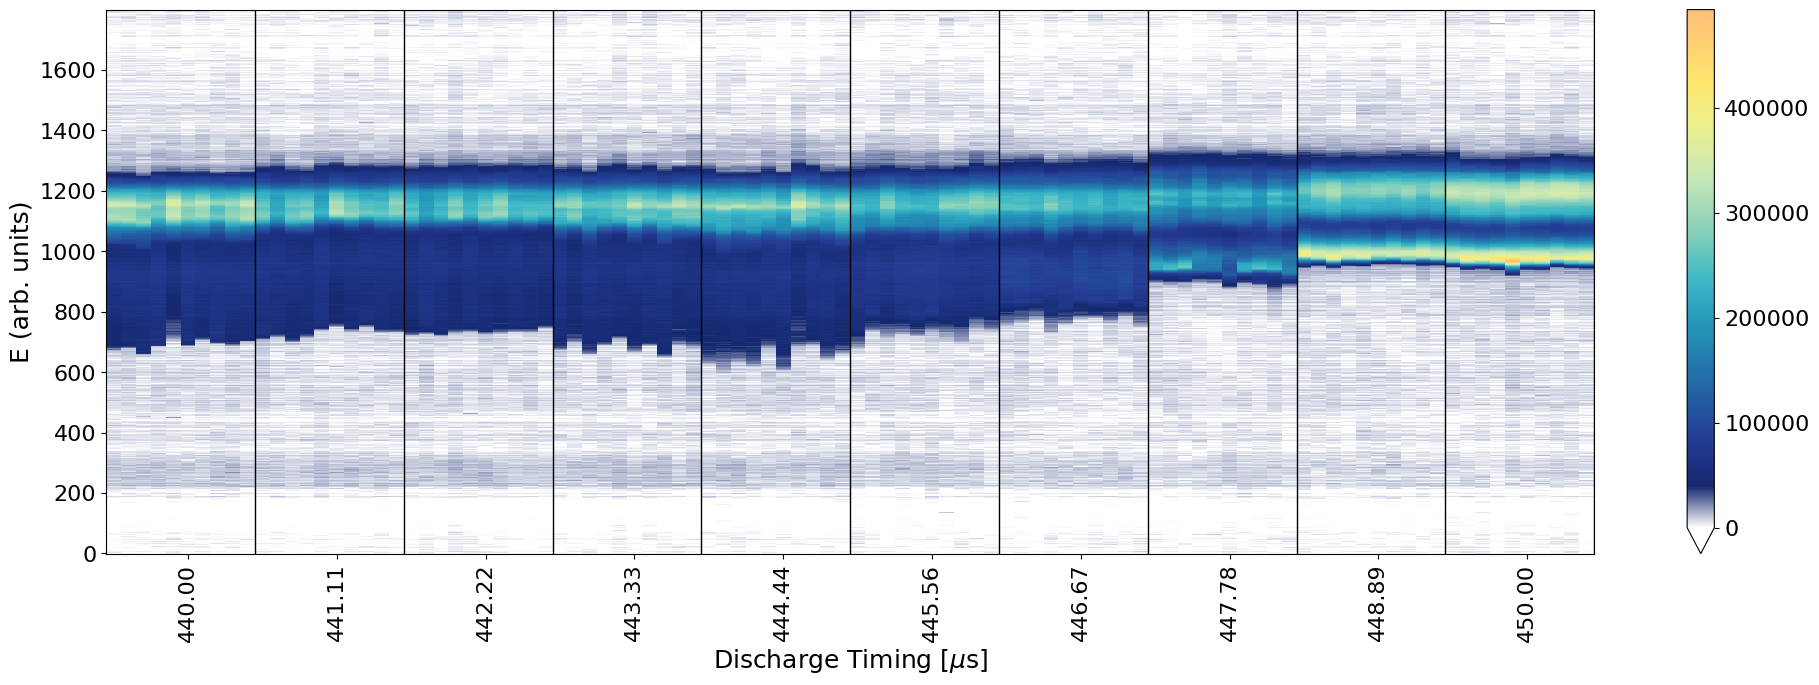

In [20]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_184810.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

fig , ax = plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')

In [24]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_184810.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

In [ ]:
fr